In [5]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


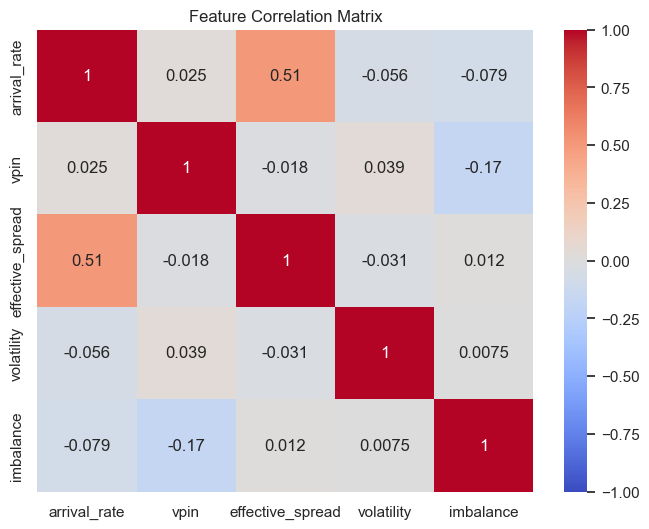

In [6]:
# Correlation Analysis
if df_ml is not None:
    features = ['arrival_rate', 'vpin', 'effective_spread', 'volatility', 'imbalance']
    corr = df_ml[features].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Feature Correlation Matrix')
    plt.show()


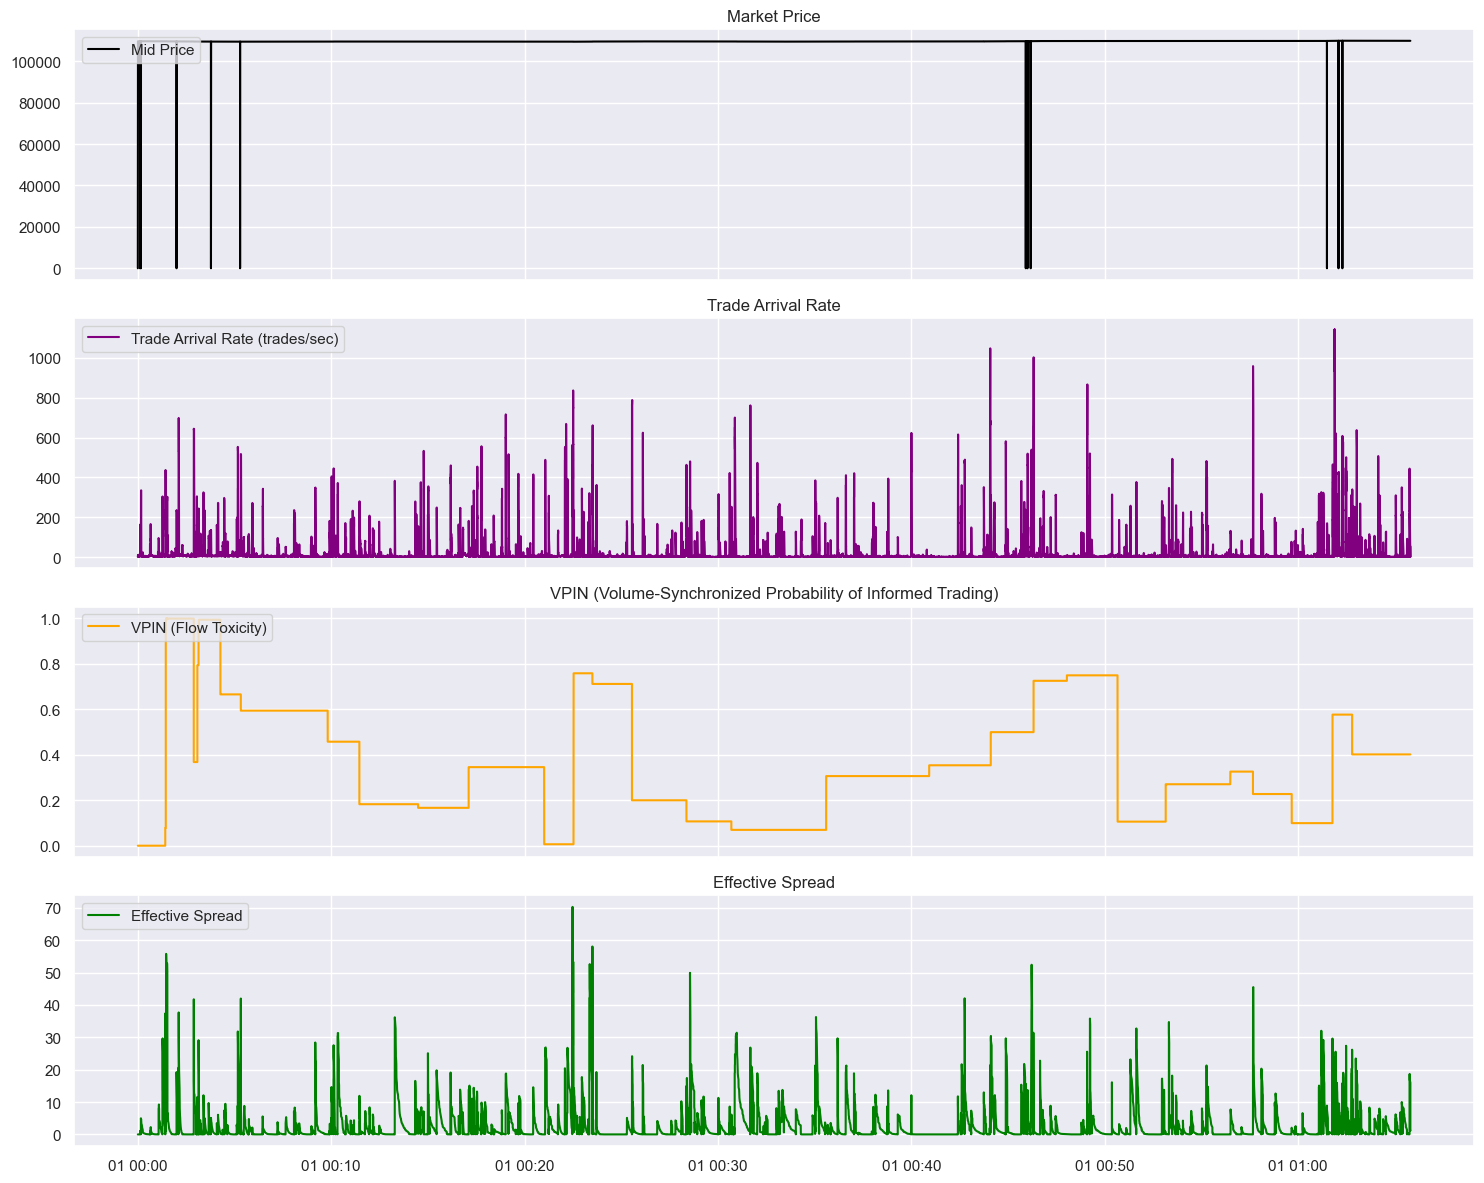

In [7]:
# Analyze New Features (ML Strategy Only)
if df_ml is not None:
    fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
    
    # Price
    axes[0].plot(df_ml.index, df_ml['midprice'], color='black', label='Mid Price')
    axes[0].set_title('Market Price')
    axes[0].legend(loc='upper left')
    
    # Arrival Rate
    axes[1].plot(df_ml.index, df_ml['arrival_rate'], color='purple', label='Trade Arrival Rate (trades/sec)')
    axes[1].set_title('Trade Arrival Rate')
    axes[1].legend(loc='upper left')
    
    # VPIN
    axes[2].plot(df_ml.index, df_ml['vpin'], color='orange', label='VPIN (Flow Toxicity)')
    axes[2].set_title('VPIN (Volume-Synchronized Probability of Informed Trading)')
    axes[2].legend(loc='upper left')
    
    # Effective Spread
    axes[3].plot(df_ml.index, df_ml['effective_spread'], color='green', label='Effective Spread')
    axes[3].set_title('Effective Spread')
    axes[3].legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()


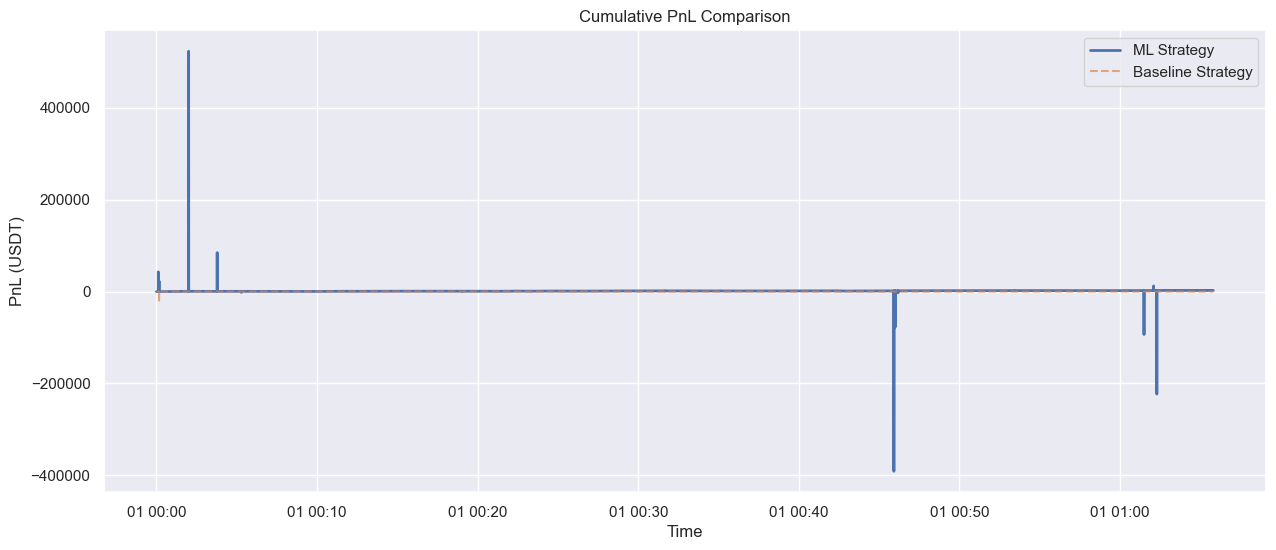

In [8]:
# Plot Equity Curves
plt.figure(figsize=(15, 6))
if df_ml is not None:
    plt.plot(df_ml.index, df_ml['pnl'], label='ML Strategy', linewidth=2)
if df_baseline is not None:
    plt.plot(df_baseline.index, df_baseline['pnl'], label='Baseline Strategy', linestyle='--', alpha=0.7)

plt.title('Cumulative PnL Comparison')
plt.ylabel('PnL (USDT)')
plt.xlabel('Time')
plt.legend()
plt.show()


In [9]:
def calculate_metrics(df, name="Strategy"):
    if df is None or df.empty:
        return
    
    # Total Return
    total_return = df['pnl'].iloc[-1]
    
    # Total Trades (Count inventory changes)
    # A change in inventory implies a trade execution
    trades = df['inventory'].diff().abs().gt(0).sum()
    
    # Sharpe Ratio (simplified, assuming risk-free rate = 0)
    # Calculate returns on equity changes
    df['returns'] = df['equity'].pct_change().fillna(0)
    
    # Annualization factor (assuming high frequency, let's say seconds)
    # If data is every 100ms, that's 10 ticks per second * 3600 * 24 * 365? 
    # Let's just use simple mean/std for now or assume 1-second bars if we resample.
    # For HFT, Sharpe is often calculated per trade or per time unit.
    # Let's resample to 1-second for stability
    df_1s = df['equity'].resample('1s').last().ffill().pct_change().fillna(0)
    sharpe = np.sqrt(365*24*60*60) * (df_1s.mean() / df_1s.std()) if df_1s.std() != 0 else 0
    
    # Max Drawdown
    rolling_max = df['equity'].cummax()
    drawdown = (df['equity'] - rolling_max)
    max_drawdown = drawdown.min()
    
    print(f"--- {name} Performance ---")
    print(f"Total PnL: {total_return:.2f} USDT")
    print(f"Total Trades: {trades}")
    print(f"Sharpe Ratio (Annualized): {sharpe:.2f}")
    print(f"Max Drawdown: {max_drawdown:.2f} USDT")
    print(f"Final Inventory: {df['inventory'].iloc[-1]:.4f} BTC")
    print("")
    
    return df_1s

print("Calculating Metrics...")
calculate_metrics(df_ml, "ML Strategy")
calculate_metrics(df_baseline, "Baseline Strategy")

Calculating Metrics...
--- ML Strategy Performance ---
Total PnL: 2527.88 USDT
Total Trades: 12202
Sharpe Ratio (Annualized): -98.18
Max Drawdown: -914058.00 USDT
Final Inventory: 0.2800 BTC

--- Baseline Strategy Performance ---
Total PnL: 1.41 USDT
Total Trades: 253
Sharpe Ratio (Annualized): nan
Max Drawdown: -19741.25 USDT
Final Inventory: 0.0000 BTC



c:\Users\patri\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


datetime
2025-11-01 00:00:00    0.0
2025-11-01 00:00:01    0.0
2025-11-01 00:00:02    0.0
2025-11-01 00:00:03    0.0
2025-11-01 00:00:04    0.0
                      ... 
2025-11-01 01:05:44    0.0
2025-11-01 01:05:45    0.0
2025-11-01 01:05:46    0.0
2025-11-01 01:05:47    0.0
2025-11-01 01:05:48    0.0
Freq: s, Name: equity, Length: 3949, dtype: float64

In [10]:
# Verify New Features
if df_ml is not None:
    print("First 5 rows of new features:")
    print(df_ml[['arrival_rate', 'vpin', 'effective_spread']].head(5))
    print("\nMean values:")
    print(df_ml[['arrival_rate', 'vpin', 'effective_spread']].mean())

First 5 rows of new features:
                               arrival_rate  vpin  effective_spread
datetime                                                           
2025-11-01 00:00:00.098000896           1.0   0.0              0.00
2025-11-01 00:00:00.205412096           2.0   0.0              0.01
2025-11-01 00:00:00.276953088           3.0   0.0              0.01
2025-11-01 00:00:00.308023040           4.0   0.0              0.01
2025-11-01 00:00:00.330718976           5.0   0.0              0.01

Mean values:
arrival_rate        176.903860
vpin                  0.381053
effective_spread      5.857526
dtype: float64


Alpha Signal Stats:
count    100000.000000
mean          0.002403
std           0.352299
min          -8.204960
25%          -0.011095
50%          -0.002300
75%           0.003253
max          31.274200
Name: alpha, dtype: float64


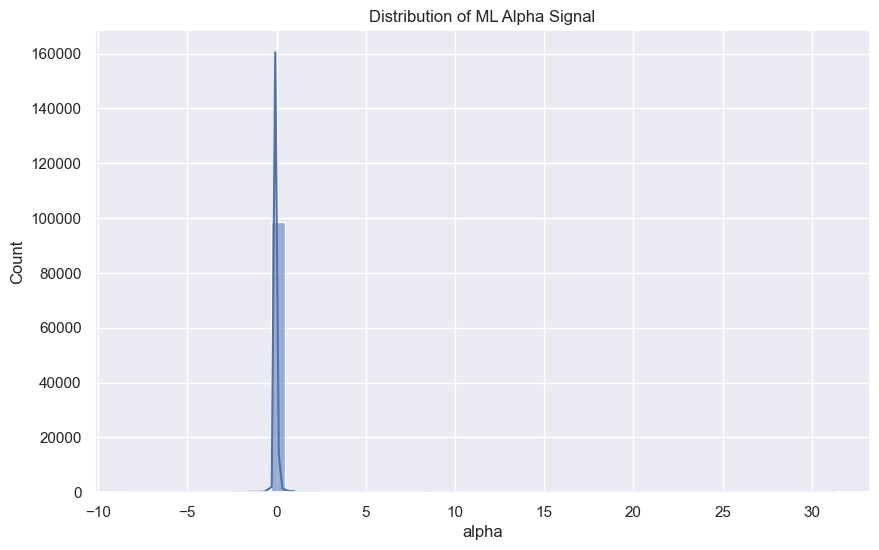

In [11]:
# Analyze Alpha Signal
if df_ml is not None:
    print("Alpha Signal Stats:")
    print(df_ml['alpha'].describe())
    
    plt.figure(figsize=(10, 6))
    sns.histplot(df_ml['alpha'], bins=50, kde=True)
    plt.title('Distribution of ML Alpha Signal')
    plt.show()

In [12]:
# Analyze Target Variable
if df_ml is not None:
    df_ml['future_return'] = df_ml['midprice'].shift(-1) - df_ml['midprice']
    print("Future Return Stats:")
    print(df_ml['future_return'].describe())
    
    print("\nMidprice Stats:")
    print(df_ml['midprice'].describe())

Future Return Stats:
count     99999.000000
mean          1.098291
std        1662.802394
min     -109855.000000
25%           0.000000
50%           0.000000
75%           0.000000
max      109864.000000
Name: future_return, dtype: float64

Midprice Stats:
count    100000.000000
mean     109568.573620
std        1257.251029
min           0.000000
25%      109471.000000
50%      109517.000000
75%      109715.000000
max      109877.000000
Name: midprice, dtype: float64


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = [15, 8]

# Define column names based on C++ output
COLUMNS = [
    'type', 'timestamp', 'imbalance', 'spread', 'microprice', 'midprice', 
    'inventory', 'equity', 'reservation_price', 'volatility', 'alpha', 
    'arrival_rate', 'vpin', 'effective_spread'
]

def load_log(filepath):
    """Loads the simulation log and preprocesses it."""
    try:
        df = pd.read_csv(filepath, names=COLUMNS, header=None)
        # Filter only TICK rows
        df = df[df['type'] == 'TICK'].copy()
        
        # Convert timestamp to datetime (assuming nanoseconds from C++ std::chrono)
        df['datetime'] = pd.to_datetime(df['timestamp'], unit='ns')
        df.set_index('datetime', inplace=True)
        
        # Calculate PnL
        df['pnl'] = df['equity'] - df['equity'].iloc[0]
        
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

# Load Data
df_ml = load_log('../data/simulation_log_ml.csv')
df_baseline = load_log('../data/simulation_log_baseline.csv')

print(f"ML Data: {len(df_ml)} rows")
if df_baseline is not None:
    print(f"Baseline Data: {len(df_baseline)} rows")


Error loading ../data/simulation_log_baseline.csv: 'utf-8' codec can't decode byte 0xff in position 0: invalid start byte
ML Data: 100000 rows


OOS Data: 50000 rows
--- OOS Strategy (Test Set) Performance ---
Total PnL: 1001.77 USDT
Total Trades: 6252
Sharpe Ratio (Annualized): nan
Max Drawdown: -911921.00 USDT
Final Inventory: 0.6700 BTC

--- OOS Baseline (Test Set) Performance ---
Total PnL: 6.12 USDT
Total Trades: 60
Sharpe Ratio (Annualized): nan
Max Drawdown: -43.88 USDT
Final Inventory: 0.0000 BTC



c:\Users\patri\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\patri\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


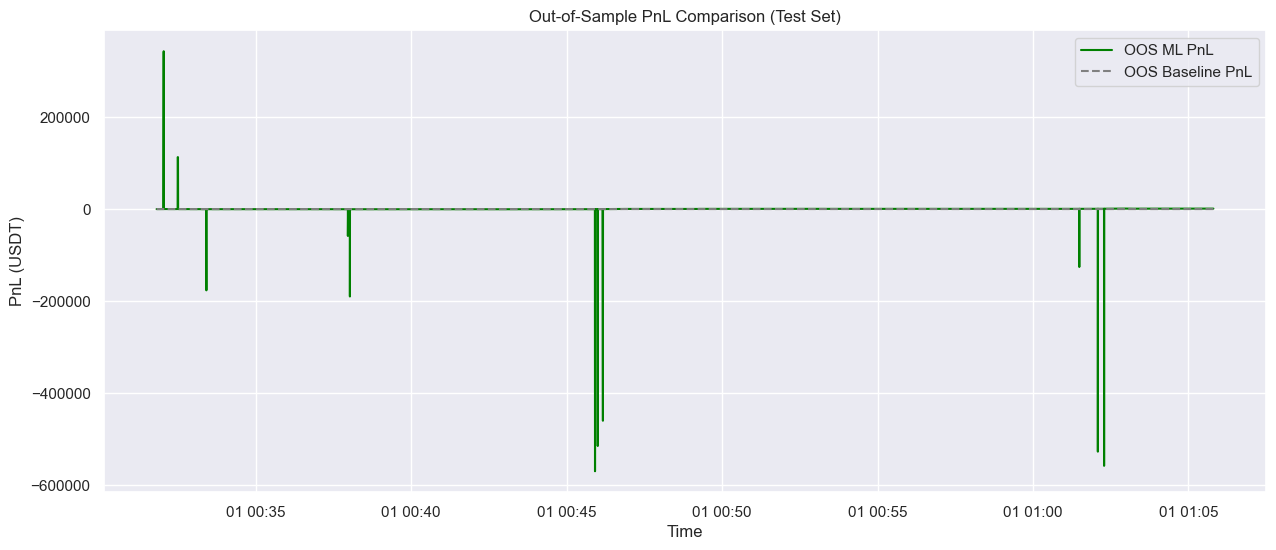

In [17]:
# Out-of-Sample (OOS) Analysis
df_oos = load_log('../data/simulation_log_test.csv')
df_oos_baseline = load_log('../data/simulation_log_test_baseline.csv')

if df_oos is not None:
    print(f"OOS Data: {len(df_oos)} rows")
    calculate_metrics(df_oos, "OOS Strategy (Test Set)")
    
    if df_oos_baseline is not None:
        calculate_metrics(df_oos_baseline, "OOS Baseline (Test Set)")

    plt.figure(figsize=(15, 6))
    plt.plot(df_oos.index, df_oos['pnl'], label='OOS ML PnL', color='green')
    if df_oos_baseline is not None:
        plt.plot(df_oos_baseline.index, df_oos_baseline['pnl'], label='OOS Baseline PnL', color='gray', linestyle='--')
    
    plt.title('Out-of-Sample PnL Comparison (Test Set)')
    plt.ylabel('PnL (USDT)')
    plt.xlabel('Time')
    plt.legend()
    plt.show()

In [ ]:
# Training Set Analysis (for comparison)
df_train = load_log('../data/simulation_log_train.csv')

if df_train is not None:
    print(f"Training Data: {len(df_train)} rows")
    calculate_metrics(df_train, "In-Sample Strategy (Train Set)")
    
    plt.figure(figsize=(15, 6))
    plt.plot(df_train.index, df_train['pnl'], label='In-Sample PnL', color='blue')
    plt.title('In-Sample PnL (Train Set)')
    plt.ylabel('PnL (USDT)')
    plt.xlabel('Time')
    plt.legend()
    plt.show()